## Detrending the seasonality from the data

Detrend the data, then normalise the residual for GP.

Geopotential units: [m^2 s^-2] \
2m temp units: [K]

In [1]:
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

import statsmodels.api as sm
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import DecomposeResult

register_matplotlib_converters()
sns.set_style("darkgrid")

In [2]:
plt.rc("figure", figsize=(8, 6))
plt.rc("font", size=7)

In [3]:
# Data
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2017.12', '2017.12'))
point_worst = data['z'].sel(lat=50, lon=225, method='nearest')
point_best = data['z'].sel(lat=19.6875, lon=270, method='nearest')

In [4]:
data.lat[19].values

array(19.6875)

In [5]:
data.lon[48].values

array(270.)

Detrend the data at (50,225) into a trend + daily + weekly seasonal component and a residual component.

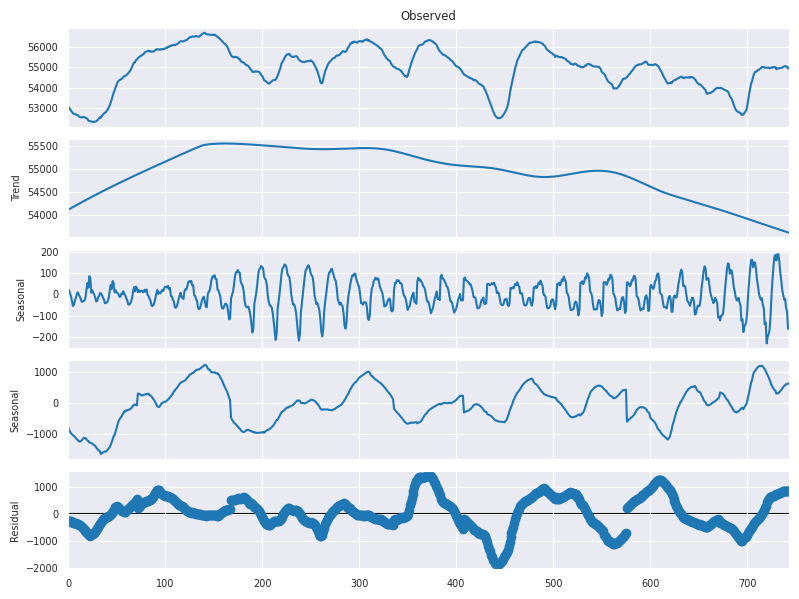

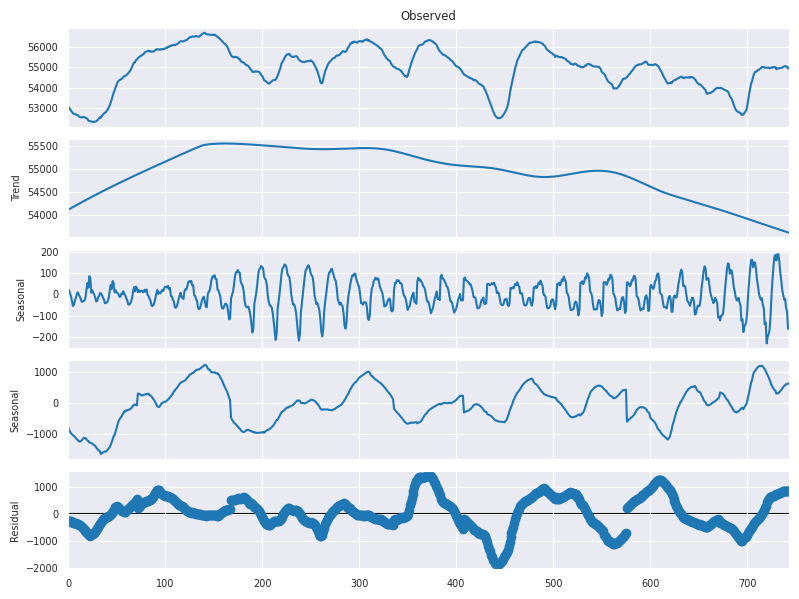

In [8]:
detrend_point_worst = MSTL(point_worst, periods=[24, 24*7])
residual_point_worst = detrend_point_worst.fit()
residual_point_worst.plot()

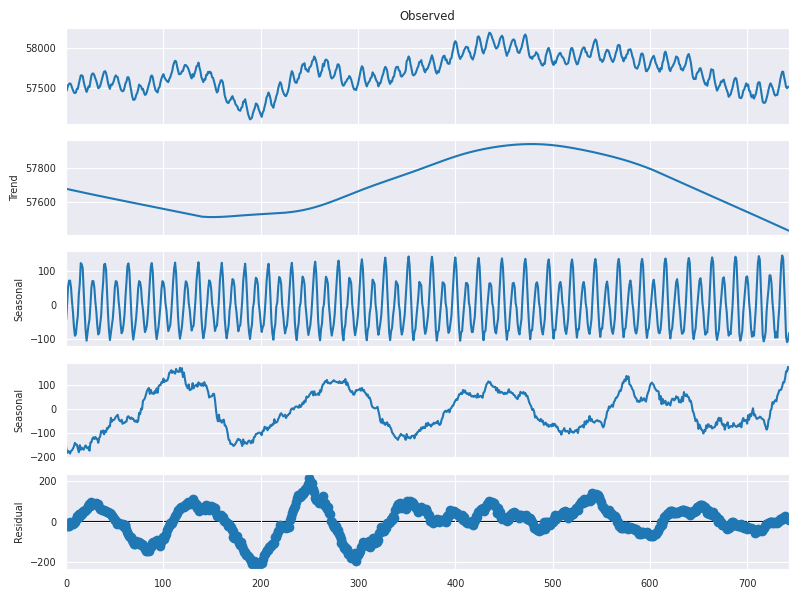

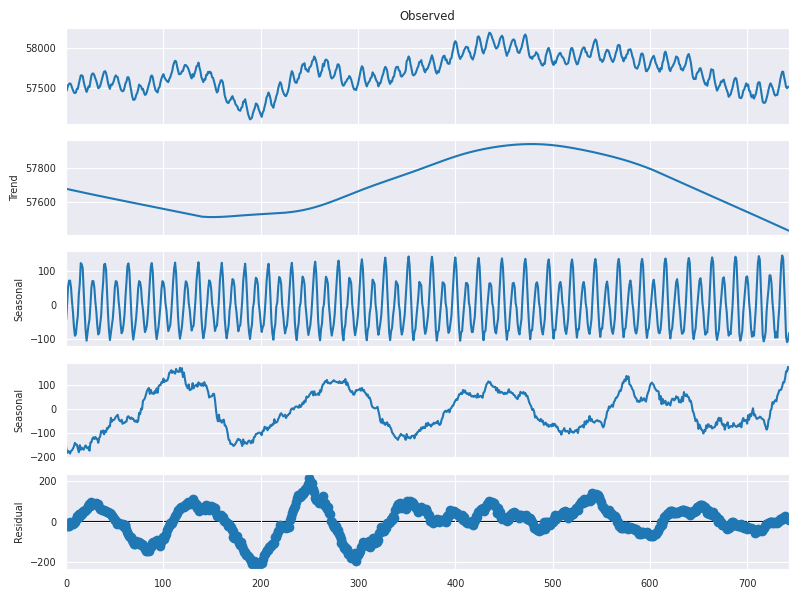

In [9]:
detrend_point_best = MSTL(point_best, periods=[24, 24*7])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()

We can forecast the trend and seasonal affects

Peak at frequency = 0.00134 cycles/hour (corresponding period = 744.00 hrs), power = 20673726.00000
Peak at frequency = 0.03091 cycles/hour (corresponding period = 32.35 hrs), power = 128554.56250
Peak at frequency = 0.05780 cycles/hour (corresponding period = 17.30 hrs), power = 16694.19336
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs), power = 3260253.25000
Peak at frequency = 0.12500 cycles/hour (corresponding period = 8.00 hrs), power = 65693.14844
Peak at frequency = 0.16667 cycles/hour (corresponding period = 6.00 hrs), power = 39073.85938


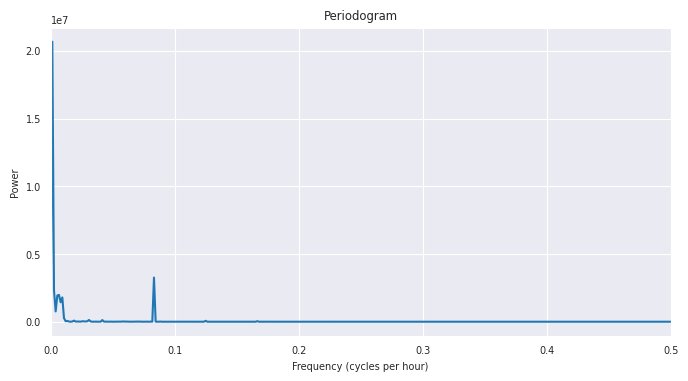

In [130]:
from scipy.signal import periodogram, find_peaks
ts = point_best.values - point_best.values.mean()
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(ts, fs=fs)
peaks, properties = find_peaks(power, height=10000, distance=10)
peak_freqs = freqs[peaks]
peak_powers = power[peaks]
for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.5)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

Peak at frequency = 0.00134 cycles/hour (corresponding period = 744.00 hrs), power = 180571360.00000
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs), power = 319862.25000
Peak at frequency = 0.15457 cycles/hour (corresponding period = 6.47 hrs), power = 23534.73633


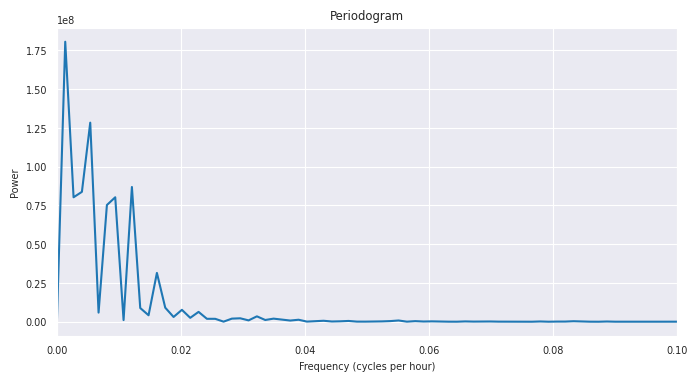

In [127]:
from scipy.signal import periodogram, find_peaks

fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_worst.values, fs=fs)
peaks, properties = find_peaks(power, height=10000, distance=50)
peak_freqs = freqs[peaks]
peak_powers = power[peaks]
for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.1)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

In [16]:
residual_point_best.resid.shape

(248,)

In [20]:
def mstl_detrend(ts, periods):
    """
    Apply MSTL decomposition to a 1D numpy array and return the residuals.
    
    Parameters
    ----------
    ts : array_like
        Time series data.
    period : array_like
        Enter multiple seasonal period you suspect in an array form. For 
        instance, if we suspect daily and weekly periodicity, we enter 
        period = [24, 24*5]
    
    Returns
    -------
    detrended_ts : numpy array
        The residual time series after removing the seasonal component.
    """
    detrend = MSTL(ts, periods=periods).fit()
    return detrend.resid

periods = [4, 4*5]

residuals = xr.apply_ufunc(
    mstl_detrend,       
    data['z'].load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# residuals for GP regression.
print(residuals)

<xarray.DataArray 'z' (lat: 32, lon: 64, time: 248)> Size: 4MB
array([[[ 303.33076391,  232.61896834,  154.78392919, ...,
          -44.04829468, -106.29780351, -195.08741801],
        [ 312.13307572,  242.46986038,  163.00359374, ...,
          -45.25566951, -117.731815  , -206.32133833],
        [ 323.55461406,  254.40688839,  176.65946617, ...,
          -45.90361506, -125.29201967, -216.71176038],
        ...,
        [ 279.00291481,  209.38173591,  127.05902582, ...,
          -34.24131049,  -70.38062926, -139.58572287],
        [ 283.59884511,  212.0261474 ,  138.09273023, ...,
          -35.34341467,  -83.072698  , -159.9308988 ],
        [ 292.33679795,  222.81546123,  145.31464834, ...,
          -41.49447357,  -94.31992884, -177.33545556]],

       [[ 199.99061683,  145.29302854,   70.15936467, ...,
           28.55043806,  -58.17528053, -138.84337907],
        [ 219.16792143,  160.45234546,   83.30819075, ...,
           23.57933613,  -73.76834217, -160.2396146 ],
        [ 

In [55]:
t2m = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/2m_temperature/*.nc', combine='by_coords')
data = t2m.sel(time=slice('2017.12', '2017.12'))
point_worst = data['t2m'].sel(lat=65, lon=84.375, method='nearest')
point_best = data['t2m'].sel(lat=2.8125, lon=196.875, method='nearest')

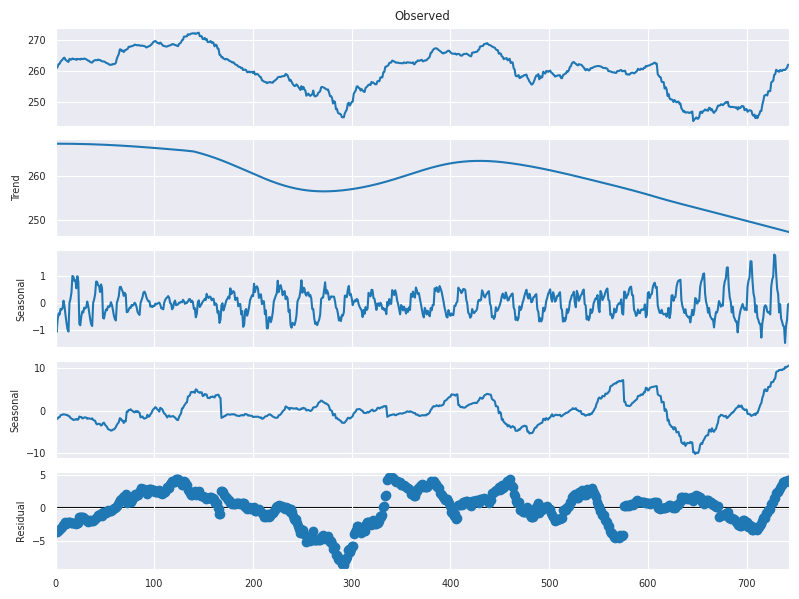

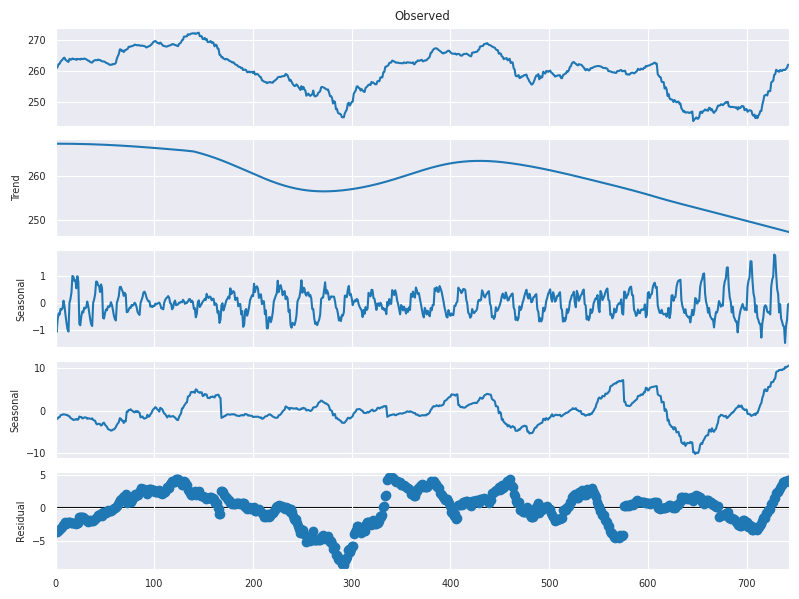

In [72]:
detrend_point_worst = MSTL(point_worst, periods=[24, 24*7])
residual_point_worst = detrend_point_worst.fit()
residual_point_worst.plot()

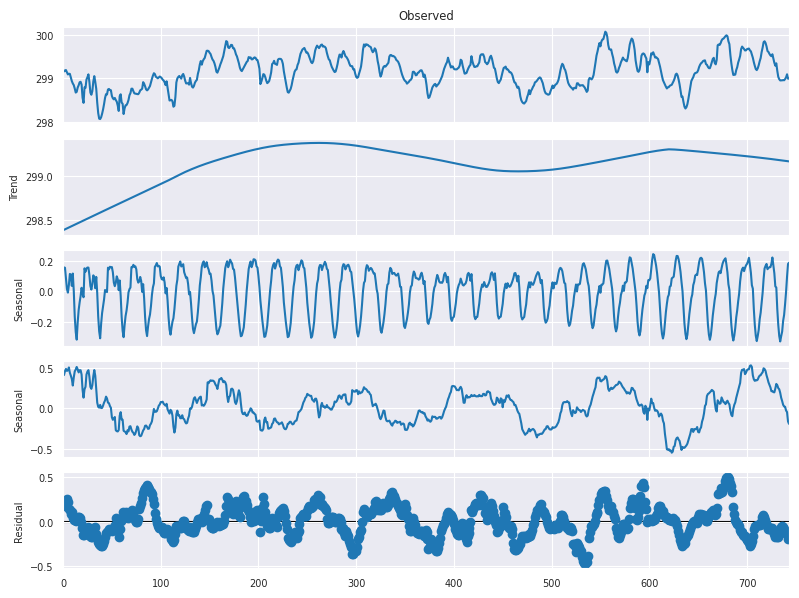

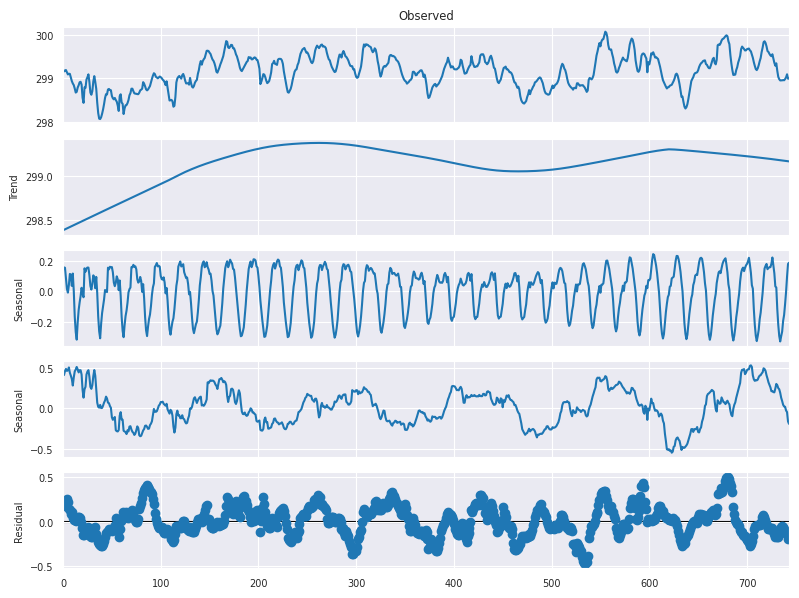

In [69]:
detrend_point_best = MSTL(point_best, periods=[24, 148])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()

Peak at frequency = 0.00269 cycles/hour (corresponding period = 372.00 days), power = 25.74665
Peak at frequency = 0.00672 cycles/hour (corresponding period = 148.80 days), power = 17.78184
Peak at frequency = 0.04167 cycles/hour (corresponding period = 24.00 days), power = 13.80849


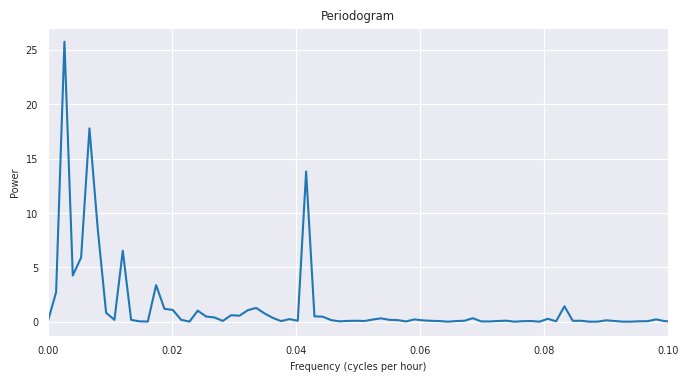

In [ ]:
from scipy.signal import periodogram, find_peaks

fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_best.values, fs=fs)
peaks, properties = find_peaks(power, height=10, distance=2)
peak_freqs = freqs[peaks]
peak_powers = power[peaks]
for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.1)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

Peak at frequency = 0.00269 cycles/hour (corresponding period = 372.00 hrs), power = 21825.47656
Peak at frequency = 0.03091 cycles/hour (corresponding period = 32.35 hrs), power = 84.52875
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs), power = 13.07959


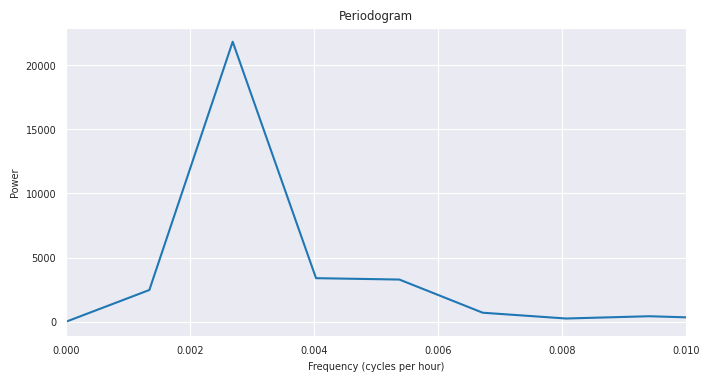

In [92]:
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_worst.values, fs=fs)
peaks, properties = find_peaks(power, height=10, distance=20)
peak_freqs = freqs[peaks]
peak_powers = power[peaks]
for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()